In [1]:
from feos import *
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from si_units import *
import warnings
warnings.filterwarnings('ignore')

sns.set_context('talk')
sns.set_palette("hls", 8)
sns.set_style('ticks')
colors = sns.palettes.color_palette('Dark2', 8)

In [5]:
pr =PureRecord(
    identifier=Identifier(), 
    molarweight=1, 
    m=1, 
    sigma=1, 
    epsilon_k=1, 
    association_sites=[{"kappa_ab": 0.1, "epsilon_k_ab": 100, "na": 1.0, "nb": 1.0}]
)
saft = EquationOfState.pcsaft(Parameters.new_pure(pr))
vle = PhaseDiagram.pure(saft, 0.5*KELVIN, 100)

In [23]:
pr = PureRecord(
    identifier=Identifier(), 
    molarweight=1, 
    rep=12,
    att=6,
    sigma=1, 
    epsilon_k=1, 
    association_sites=[{"kappa_ab": 0.1, "epsilon_k_ab": 100, "na": 1.0, "nb": 1.0}]
)
uv = EquationOfState.uvtheory(Parameters.new_pure(pr), perturbation="WCA")
vle_uv = PhaseDiagram.pure(uv, 0.5*KELVIN, 100)

In [24]:
s = State(uv, temperature=1* KELVIN, density = 0.8 / NAV / ANGSTROM**3)
s.internal_energy(Contributions.Residual)

-1.4600458070924463e-21  J

In [25]:

State.critical_point(uv)

|temperature|density|
|-|-|
|7.31457 K|98.25002 kmol/m³|

In [26]:
State.critical_point(saft)

|temperature|density|
|-|-|
|7.70277 K|113.18658 kmol/m³|

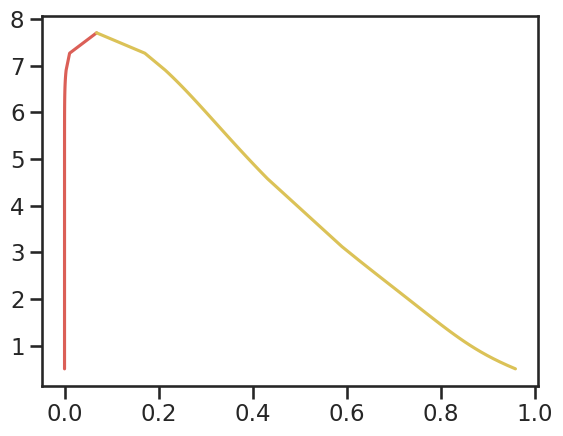

In [27]:
plt.plot(vle.vapor.density*NAV*ANGSTROM**3, vle.vapor.temperature/KELVIN)
plt.plot(vle.liquid.density*NAV*ANGSTROM**3, vle.liquid.temperature/KELVIN)